<a href="https://colab.research.google.com/github/CelestineAnyaegbunamUgwu/Livestock_disease_image_classifier_CNN/blob/main/livstock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/devang03mgr/cattle-diseases-datasets"
)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: john5cele@yahoo.com
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/devang03mgr/cattle-diseases-datasets


100%|██████████| 257M/257M [00:02<00:00, 133MB/s]


In [10]:


train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())

print(CLASS_NAMES)

Found 2596 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
['foot-and-mouth', 'healthy', 'lumpy']


In [11]:
# Install required packages (Run if necessary)
!pip install shap grad-cam tf-explain


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d530180620291cb36a557b33ce91bb4d1dd19b2bcc64ff23258f70f9bceb9ca4
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [12]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tf_explain.core.grad_cam import GradCAM

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [14]:
# Create output folders

OUTPUT_DIR = "outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Folders created successfully.")


Folders created successfully.


In [15]:
# Dataset Description

dataset_description = pd.DataFrame({
    "Feature": ["Dataset Name", "Number of Classes", "Image Size", "Classes"],
    "Value": [
        "Cattle Disease Dataset",
        len(CLASS_NAMES),
        str(IMG_SIZE),
        ", ".join(CLASS_NAMES)
    ]
})

dataset_description.to_csv(os.path.join(TABLE_DIR, "dataset_description.csv"), index=False)

dataset_description


,Feature,Value
0,Dataset Name,Cattle Disease Dataset
1,Number of Classes,3
2,Image Size,"(224, 224)"
3,Classes,"foot-and-mouth, healthy, lumpy"


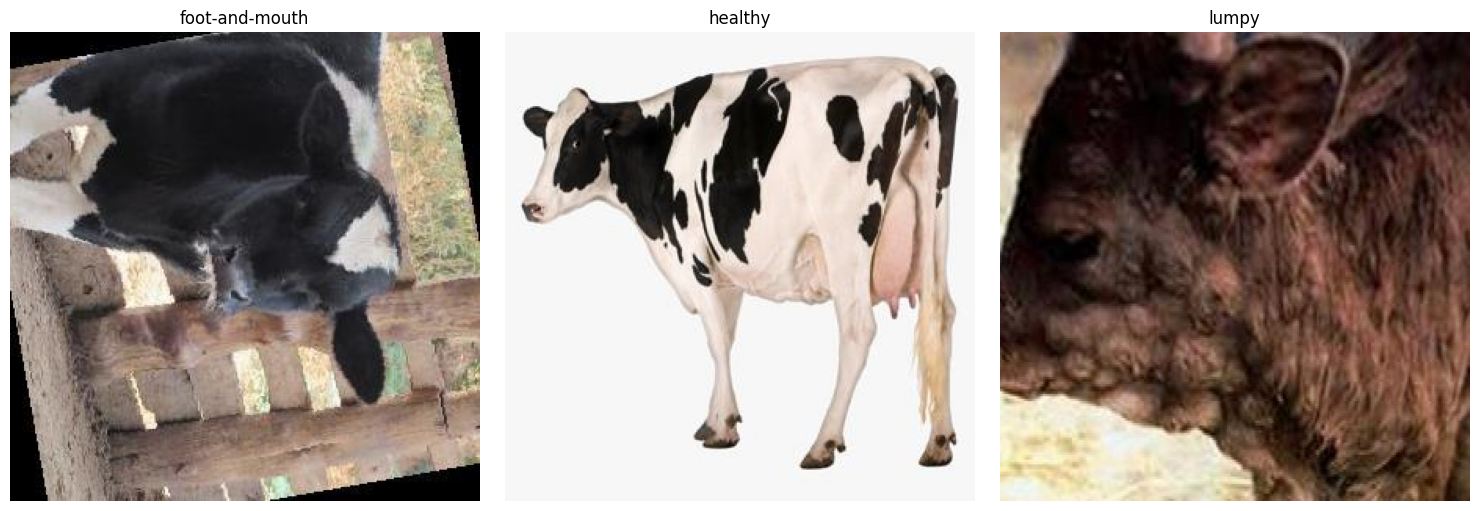

In [16]:
# Display sample images

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(15,5))

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)

    img = plt.imread(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dataset_samples.pdf"))
plt.show()


In [17]:
# Custom CNN

custom_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(len(CLASS_NAMES), activation='softmax')
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
base_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_mobilenet.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

mobilenet_model = Model(inputs=base_mobilenet.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
# Training function

EPOCHS = 10

def train_model(model, model_name):

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS
    )

    model.save(os.path.join(MODEL_DIR, f"{model_name}.h5"))

    # Accuracy plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title(f"{model_name} Accuracy")
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_accuracy.pdf"))
    plt.close()

    # Loss plot
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title(f"{model_name} Loss")
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_loss.pdf"))
    plt.close()

    return history

In [21]:
# Train all models

history_custom = train_model(custom_cnn, "Custom_CNN")
history_mobile = train_model(mobilenet_model, "MobileNetV2")
history_resnet = train_model(resnet_model, "ResNet50")

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.5505 - loss: 0.9287 - val_accuracy: 0.6728 - val_loss: 0.7358
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 406s 5s/step - accuracy: 0.6637 - loss: 0.7736 - val_accuracy: 0.7022 - val_loss: 0.7118
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 395s 5s/step - accuracy: 0.6714 - loss: 0.7530 - val_accuracy: 0.7083 - val_loss: 0.6938
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.6980 - loss: 0.7001 - val_accuracy: 0.7238 - val_loss: 0.6627
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 396s 5s/step - accuracy: 0.7011 - loss: 0.6991 - val_accuracy: 0.7392 - val_loss: 0.6351
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 398s 5s/step - accuracy: 0.7076 - loss: 0.6829 - val_accuracy: 0.7485 - val_loss: 0.6169
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.7165 - loss: 0.6602 - val_accuracy: 0.7485 - val_loss: 0.6379
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 397s 5s/step - accuracy: 0.7354 - loss: 0.6388 - val_accuracy: 0.7623 - v

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.6498 - loss: 0.7741 - val_accuracy: 0.7978 - val_loss: 0.5180
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8267 - loss: 0.4620 - val_accuracy: 0.8596 - val_loss: 0.3745
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.8648 - loss: 0.3641 - val_accuracy: 0.8657 - val_loss: 0.3386
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8833 - loss: 0.3189 - val_accuracy: 0.8873 - val_loss: 0.3219
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.8948 - loss: 0.2915 - val_accuracy: 0.8796 - val_loss: 0.2964
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.8956 - loss: 0.2907 - val_accuracy: 0.9012 - val_loss: 0.2731
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9025 - loss: 0.2557 - val_accuracy: 0.8966 - val_loss: 0.2871
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.9114 - loss: 0.2420 - val_accuracy: 0.9028 - v

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 695s 8s/step - accuracy: 0.4364 - loss: 1.0633 - val_accuracy: 0.5309 - val_loss: 1.0241
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 679s 8s/step - accuracy: 0.5104 - loss: 1.0211 - val_accuracy: 0.5525 - val_loss: 0.9899
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 675s 8s/step - accuracy: 0.5185 - loss: 1.0027 - val_accuracy: 0.5710 - val_loss: 0.9896
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 673s 8s/step - accuracy: 0.5181 - loss: 0.9862 - val_accuracy: 0.5633 - val_loss: 0.9618
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 674s 8s/step - accuracy: 0.5250 - loss: 0.9776 - val_accuracy: 0.5448 - val_loss: 0.9580
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 673s 8s/step - accuracy: 0.5227 - loss: 0.9775 - val_accuracy: 0.5540 - val_loss: 0.9494
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 681s 8s/step - accuracy: 0.5289 - loss: 0.9655 - val_accuracy: 0.5602 - val_loss: 0.9531
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 674s 8s/step - accuracy: 0.5378 - loss: 0.9602 - val_accuracy: 0.5664 - v

In [22]:
# Evaluation Function

def evaluate_model(model, model_name):

    predictions = model.predict(val_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = val_generator.classes

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value": [acc, precision, recall, f1]
    })

    results.to_csv(os.path.join(TABLE_DIR, f"{model_name}_metrics.csv"), index=False)

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(TABLE_DIR, f"{model_name}_classification_report.csv")
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} Confusion Matrix")

    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_confusion_matrix.pdf"))
    plt.close()

    return results


In [23]:
# Evaluate models

custom_results = evaluate_model(custom_cnn, "Custom_CNN")
mobile_results = evaluate_model(mobilenet_model, "MobileNetV2")
resnet_results = evaluate_model(resnet_model, "ResNet50")

21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step


In [24]:
# Comparative Results Table

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Accuracy": [
        custom_results.iloc[0,1],
        mobile_results.iloc[0,1],
        resnet_results.iloc[0,1]
    ],
    "Precision": [
        custom_results.iloc[1,1],
        mobile_results.iloc[1,1],
        resnet_results.iloc[1,1]
    ],
    "Recall": [
        custom_results.iloc[2,1],
        mobile_results.iloc[2,1],
        resnet_results.iloc[2,1]
    ],
    "F1-Score": [
        custom_results.iloc[3,1],
        mobile_results.iloc[3,1],
        resnet_results.iloc[3,1]
    ]
})

comparison_df.to_csv(os.path.join(TABLE_DIR, "comparison_results.csv"), index=False)

comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.743827,0.758083,0.743827,0.740297
1,MobileNetV2,0.910494,0.911314,0.910494,0.910657
2,ResNet50,0.560185,0.568241,0.560185,0.512161


In [25]:
# Grad-CAM Visualization

def generate_gradcam(model, image, class_index, layer_name, save_name):

    data = ([image], None)

    explainer = GradCAM()

    grid = explainer.explain(
        data,
        model,
        class_index=class_index,
        layer_name=layer_name
    )

    plt.figure(figsize=(6,6))
    plt.imshow(grid)
    plt.axis('off')

    plt.savefig(os.path.join(FIG_DIR, save_name))
    plt.close()


In [26]:
# Example Grad-CAM generation

sample_batch = next(val_generator)
sample_image = sample_batch[0][0]
sample_label = np.argmax(sample_batch[1][0])

generate_gradcam(
    mobilenet_model,
    sample_image,
    sample_label,
    "Conv_1",
    "MobileNetV2_GradCAM.pdf"
)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_11']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


In [34]:
import numpy as np
#import tensorflow as tf
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations of the last conv layer
    # as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. This is the gradient of the output neuron with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. We multiply each channel in the feature map array by "how important this channel is"
    # with regard to the top predicted class, then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# --- HOW TO USE IT ---
# 1. Find your last convolutional layer name using: model.summary()
# 2. Generate the heatmap:
# heatmap = make_gradcam_heatmap(your_preprocessed_image, model, "name_of_last_conv_layer")

# 3. Plot it:
# plt.matshow(heatmap)
# plt.show()

In [35]:
# Model Architecture Summary

architecture_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50"],
    "Type": [
        "CNN from scratch",
        "Transfer Learning",
        "Transfer Learning"
    ],
    "Input Size": [
        "224x224x3",
        "224x224x3",
        "224x224x3"
    ]
})

architecture_df.to_csv(
    os.path.join(TABLE_DIR, "model_architecture.csv"),
    index=False
)

architecture_df


,Model,Type,Input Size
0,Custom CNN,CNN from scratch,224x224x3
1,MobileNetV2,Transfer Learning,224x224x3
2,ResNet50,Transfer Learning,224x224x3
